In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data=pd.read_csv('smartPhones.csv')

In [ ]:
data.head()

,model,price,rating,sim,processor,ram,battery,display,camera,card,os
0,OnePlus 11 5G,"₹54,999",89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Gen2, Octa Core, 3.2 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 100W Fast Charging,"6.7 inches, 1440 x 3216 px, 120 Hz Display wit...",50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13
1,OnePlus Nord CE 2 Lite 5G,"₹19,989",81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 695, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.59 inches, 1080 x 2412 px, 120 Hz Display wi...",64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12
2,Samsung Galaxy A14 5G,"₹16,499",75.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Exynos 1330, Octa Core, 2.4 GHz Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery with 15W Fast Charging,"6.6 inches, 1080 x 2408 px, 90 Hz Display with...",50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13
3,Motorola Moto G62 5G,"₹14,999",81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 695, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with Fast Charging,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12
4,Realme 10 Pro Plus,"₹24,999",82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1080, Octa Core, 2.6 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13


# Data assessing


`column : model`

- i will extract the first name of model , but the problem is some are in small letter some in capital so first we are going to convert whole column into small then do extraction of first name.

- Since there are lot of models of different phones , but ofcourse we cant keep them all so we are goinng to keep top 15 mobile phone not their model just their name.
(e.g) ONEPLUS , SAMSUNG , MOTOROLLA , REALME , OPPO , XIOMI , VIVO , POCO  , APPLE , INFINX , TECNO , NOKIA ,OTHER -> these will be our mobile name
we make new column name called mobile from it.

`column : price`

- have to remove ',' and that money sign from price column and have to convert this column into int

`column : rating`

- There are missing values in rating column.

`colum : sim`
- now , from this colum we can do feature engineering , since this column is very ambigious , we can make THREE new column form this one column.

--> 1st column '5G' , which will contain yes if we found 5G in the sim column else No.

--> 2nd column 'NFC' , which will contain yes if we found NFC in sim colum else no

--> 3rd column 'IR BLASTER' which will contain yes if sim col contain IR BLASTER in it else no.

after we will simply drop sim column :).

`column : processor `

- NOW , this column is also very ambigous , we can extract lot of information from this single column by feature engineering
we can make following new column.

--> 'processor brands' which will contain the name of processor brand name , it will contain this values (snapdragon , bionic , helio , exynos , others)

--> 'core' which will contain categories like octa core and hexa core if come else other

`column ram`

- we can also do feature engineering on this column and can extract 2 new column

--> 'RAM' which will contain numeric value only of ram like 4 , 8, 16 etc

--> 'Memory ' which will contain the inbbuilt memory
like 64 , 128 , 256 etc

`column : battery `


- in this column there are some rows which contain value differnt values like inches , display ,  so will only keep rows contain battery word in it else drop rows ..

- we can make 1 new column from this which is battery column but it will contain only numeic value like 5000 , 4700 etc


`column : display`

- this column is also rich in information so we have to do feature engineering in order to extract usefull information from it we can extract follwing information form this column

--> 'inches' which will contain the numeric value of inches of mobile
--> 'x_resolution ' which will contain the x resoltion.
--> 'y_resolution' which will contain y resolution .

`column : camera`

- This is column is also rich in infomation we can extract following usefull column form this column

--> 'total_rear_mp'  Sum up all rear camera megapixels to get the total power of the rear setup.

Example: 50 MP + 48 MP + 32 MP → 130 MP

--> 'total_rear_camera' which will contain triple , dual , one categories

--> 'front_mp' which will contain the value of front megapixel like 16 , 32 etc

--> 'total_front_camera' which will contain the value of front camera.

`colum : card`

- we can make one new column from this column whihc will contain yes or not if memory card supported or not

`column : os`

we can make one new column from this column and that will contain two categories one is andorid and second one is ios ..








In [ ]:
## Exporting data for manual assesment

#with pd.ExcelWriter('smartPhone.xlsx') as writer:
 #   data.to_excel(writer)

# what is done so far..
`column : model`
- extracted brands name from this column and make new column called  brands and then dropped it.

`column : rating`
- since there were some arround 130 missing values in rating and instead of droppin it , handled them through random rating so the distribution remain same

`column : sim`
- sucessfully extracted 3 new column , has 5G , has_NFC, has_IR_BLASTER , and drop the sim column as well

`column : processor`:

- successfully extracted two new column called processsor name and core , and then drop this processor column


`column : ram`

- succesfully extracted two new columns RAM and inbuilt memeory and drop the ram col..

``




In [ ]:
data['brands']=data['model'].str.strip().str.lower().str.split(' ',expand=True)[0]

In [ ]:
data['brands'].value_counts()

,count
brands,
samsung,135
xiaomi,135
vivo,111
realme,97
oppo,88
motorola,53
apple,47
oneplus,42
poco,41


In [ ]:
def fetch_brand(brand):
  if brand in ['oneplus','samsung','motorola','realme','oppo','xiaomi','vivo','poco','apple','infinix','tecno','nokia' ,'huawei' ,'googel' ]:
    return brand
  else:
    return 'other'



In [ ]:
data['brands']=data['brands'].apply(fetch_brand)

In [ ]:
data['brands'].value_counts()

,count
brands,
other,163
samsung,135
xiaomi,135
vivo,111
realme,97
oppo,88
motorola,53
apple,47
oneplus,42


In [ ]:
data.drop(columns=['model'],inplace=True)

In [ ]:
data.sample(10)

,price,rating,sim,processor,ram,battery,display,camera,card,os,brands
617,"₹22,999",83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 920 5G, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.4 inches, 1080 x 2400 px, 90 Hz Display with...",48 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,realme
493,"₹60,990",86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 135W Fast Charging,"6.8 inches, 1080 x 2400 px, 120 Hz Display",64 MP + 8 MP + 2 MP Triple Rear & 8 MP Front C...,Android v12,No FM Radio,other
104,"₹19,990",82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 800U , Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",4310 mAh Battery with 50W Fast Charging,"6.43 inches, 1080 x 2400 px Display with Punch...",48 MP Quad Rear & 16 MP Front Camera,"Memory Card Supported, upto 256 GB",Android v11,oppo
726,"₹1,62,990",89.0,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi, NFC, IR Blaster","Snapdragon 888, Octa Core, 2.84 GHz Processor","8 GB RAM, 512 GB inbuilt",4600 mAh Battery with 66W Fast Charging,"7.8 inches, 2200 x 2480 px, 120 Hz Display wit...",Foldable Display,50 MP + 13 MP + 8 MP Triple Rear & 10.7 MP Fro...,"Memory Card (Hybrid), upto 256 GB",huawei
420,"₹1,29,990",76.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core Processor","6 GB RAM, 256 GB inbuilt",3200 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px, 120 Hz Display",48 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v16,apple
17,"₹45,999",86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","16 GB RAM, 256 GB inbuilt",4700 mAh Battery with 80W Fast Charging,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",50 MP + 8 MP + 2 MP Triple Rear & 32 MP Front ...,Android v13,No FM Radio,oppo
509,"₹15,499",77.0,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi","Helio G96, Octa Core, 2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.6 inches, 1080 x 2412 px, 120 Hz Display wit...",50 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card Supported, upto 256 GB",Android v11,realme
587,"₹16,499",78.0,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi","Octa Core, 2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.6 inches, 1080 x 2408 px Display with Water ...",50 MP Quad Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v12,samsung
538,"₹10,799",74.0,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi, IR Blaster","Helio G99, Octa Core, 2.2 GHz Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery with 18W Fast Charging,"6.58 inches, 1080 x 2400 px, 90 Hz Display wit...",50 MP + 2 MP + 2 MP Triple Rear & 8 MP Front C...,"Memory Card Supported, upto 512 GB",Android v12,poco
614,"₹28,990",84.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 6 Gen 1, Octa Core, 2.2 GHz Processor","8 GB RAM, 256 GB inbuilt",5000 mAh Battery with 80W Fast Charging,"6.7 inches, 1080 x 2400 px, 120 Hz Display wit...",108 MP + 13 MP + 2 MP Triple Rear & 32 MP Fron...,Memory Card Supported,Android v13,vivo


<ipython-input-12-671310d15c8f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['rating'])


<Axes: xlabel='rating', ylabel='Density'>

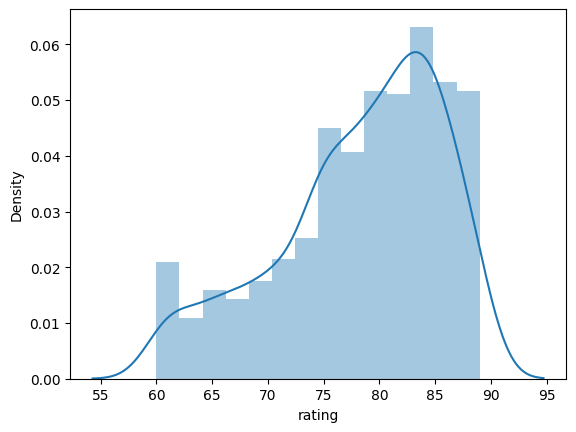

In [ ]:
sns.distplot(data['rating'])

In [ ]:
# In this cell, replacing NaN values in the rating column by taking random values
# from all over the column so the distribution remains the same.

non_null_values = data['rating'].dropna()

size_of_null_values = data['rating'].isna().sum()

imputed_values = np.random.choice(non_null_values, size=size_of_null_values, replace=True)

# Corrected line below
data.loc[data['rating'].isna(), 'rating'] = imputed_values


In [ ]:
data['rating'].isna().sum()

np.int64(0)

<ipython-input-15-671310d15c8f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['rating'])


<Axes: xlabel='rating', ylabel='Density'>

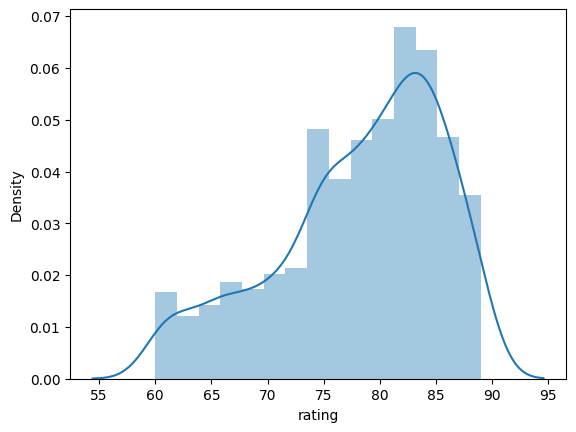

In [ ]:
sns.distplot(data['rating'])

In [ ]:
data['sim'].sample(10)

,sim
509,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi"
648,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi"
529,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi, NFC"
435,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC"
820,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi, NFC"
311,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC"
277,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC"
146,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC"
91,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC"
405,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi"


In [ ]:
data['has_5G'] = data['sim'].apply(lambda x:1 if '5G' in x else 0 )

In [ ]:
data['has_5G'].value_counts()

,count
has_5G,
1,549
0,471


In [ ]:
data['has_NFC'] = data['sim'].apply(lambda x:1 if 'NFC' in x else 0 )
data['has_IR_BLASTER'] = data['sim'].apply(lambda x:1 if 'IR Blaster' in x else 0 )

In [ ]:
data['has_NFC'].value_counts()

,count
has_NFC,
0,627
1,393


In [ ]:
data['has_IR_BLASTER'].value_counts()

,count
has_IR_BLASTER,
0,861
1,159


In [ ]:
data.drop(columns=['sim'],inplace=True)

In [ ]:
data.head()


,price,rating,processor,ram,battery,display,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER
0,"₹54,999",89.0,"Snapdragon 8 Gen2, Octa Core, 3.2 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 100W Fast Charging,"6.7 inches, 1440 x 3216 px, 120 Hz Display wit...",50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13,oneplus,1,1,0
1,"₹19,989",81.0,"Snapdragon 695, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.59 inches, 1080 x 2412 px, 120 Hz Display wi...",64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,oneplus,1,0,0
2,"₹16,499",75.0,"Exynos 1330, Octa Core, 2.4 GHz Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery with 15W Fast Charging,"6.6 inches, 1080 x 2408 px, 90 Hz Display with...",50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13,samsung,1,0,0
3,"₹14,999",81.0,"Snapdragon 695, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with Fast Charging,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,motorola,1,0,0
4,"₹24,999",82.0,"Dimensity 1080, Octa Core, 2.6 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13,realme,1,0,0


In [ ]:
data['processor'].sample(20)

,processor
887,"Helio G96, Octa Core, 2.05 GHz Processor"
440,"Snapdragon 720G, Octa Core, 2.3 GHz Processor"
526,"Snapdragon 8 Gen1, Octa Core, 3 GHz Processor"
649,"Kirin 9000, Octa Core, 3.13 GHz Processor"
632,"Helio P35, Octa Core, 2.3 GHz Processor"
638,"Helio G96, Octa Core, 2.05 GHz Processor"
694,"Exynos 7904, Octa Core, 1.8 GHz Processor"
588,"Helio G35, Octa Core, 2.3 GHz Processor"
9,"Dimensity 1300, Octa Core, 3 GHz Processor"
606,"A13 Bionic, Hexa Core, 2.65 GHz Processor"


In [ ]:
def fetch_processor_brand(processor):
  if 'snapdragon' in processor.lower():
    return 'snapdragon'
  elif 'dimensity' in processor.lower():
    return 'dimensity'
  elif 'exynos' in processor.lower():
    return 'exynos'
  elif 'helio' in processor.lower():
    return 'helio'
  else:
    return 'other'


In [ ]:
data['processor_brands']=data['processor'].apply(fetch_processor_brand)

In [ ]:
data['processor_brands'].value_counts()

,count
processor_brands,
snapdragon,413
helio,202
other,178
dimensity,177
exynos,50


In [ ]:
def fetch_core(processor):
  if 'octa' in processor.lower():
    return 'octa'
  elif 'hexa' in processor.lower():
    return 'hexa'
  elif 'quad' in processor.lower():
    return 'quad'
  else:
    return 'other'

In [ ]:
data['core']=data['processor'].apply(fetch_core)

In [ ]:
data['core'].value_counts()

,count
core,
octa,899
other,43
hexa,39
quad,39


In [ ]:
data.drop(columns=['processor'],inplace=True)

In [ ]:
data.sample(20)

,price,rating,ram,battery,display,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core
721,"₹1,07,990",76.0,"16 GB RAM, 512 GB inbuilt",6000 mAh Battery with 65W Fast Charging,"6.78 inches, 1080 x 2448 px, 165 Hz Display",Dual Display,50 MP + 13 MP + 5 MP Triple Rear & 12 MP Front...,Memory Card Not Supported,other,1,1,0,dimensity,octa
272,"₹54,300",89.0,"12 GB RAM, 128 GB inbuilt",5003 mAh Battery with 30W Fast Charging,"6.71 inches, 1440 x 3120 px, 120 Hz Display wi...",50 MP + 48 MP + 12 MP Triple Rear & 11.1 MP Fr...,Android v12,No FM Radio,other,1,1,0,other,octa
214,"₹10,999",73.0,"4 GB RAM, 128 GB inbuilt",5000 mAh Battery,"6.5 inches, 1600 x 720 px, 90 Hz Display with ...",50 MP + 2 MP Triple Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v12,other,1,0,0,dimensity,octa
135,"₹22,999",87.0,"8 GB RAM, 256 GB inbuilt",5000 mAh Battery with 67W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,"Memory Card (Hybrid), upto 1 TB",Android v11,xiaomi,1,0,1,snapdragon,octa
84,"₹13,999",75.0,"6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 15W Fast Charging,"6.5 inches, 720 x 1600 px, 90 Hz Display with ...",50 MP + 2 MP Dual Rear & 5 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v12,samsung,1,0,0,dimensity,octa
701,"₹11,999",71.0,"4 GB RAM, 64 GB inbuilt",5050 mAh Battery with 18W Fast Charging,"6.5 inches, 720 x 1600 px, 90 Hz Display with ...",50 MP + 2 MP + 2 MP Triple Rear & 8 MP Front C...,"Memory Card Supported, upto 512 GB",Android v11,nokia,0,0,0,other,octa
776,"₹24,990",83.0,"8 GB RAM, 128 GB inbuilt",5160 mAh Battery with 67W Fast Charging,"6.67 inches, 2400 x 1080 px, 120 Hz Display wi...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,"Memory Card (Hybrid), upto 1 TB",Android v11,xiaomi,1,0,1,dimensity,octa
877,"₹32,990",84.0,"8 GB RAM, 256 GB inbuilt",5000 mAh Battery with 80W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",64 MP + 8 MP + 2 MP Triple Rear & 32 MP Front ...,Memory Card Supported,Android v13,vivo,1,0,0,snapdragon,octa
710,"₹25,595",81.0,"6 GB RAM, 128 GB inbuilt",4300 mAh Battery with 30W Fast Charging,"6.49 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 16 MP Front Camera,"Memory Card Supported, upto 512 GB",Android v10,oneplus,1,1,0,snapdragon,octa
412,"₹18,999",80.0,"6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 30W Fast Charging,"6.6 inches, 1080 x 2412 px, 144 Hz Display wit...",48 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card Supported, upto 1 TB",Android v11,realme,1,0,0,snapdragon,octa


In [ ]:
data['RAM']=data['ram'].str.split(' ',expand = True)[0]
data['inbuit_memory']=data['ram'].str.split(' ',expand=True)[2]

In [ ]:
data.drop(columns=['ram'],inplace=True)

In [ ]:
data=data[data['RAM'].str.contains('GB', na=False)]

In [ ]:
data=data[data['inbuit_memory'].str.contains('GB',na=False)]

In [ ]:
data['inbuit_memory']=data['inbuit_memory'].str.replace('GB',' ').astype(int)

<ipython-input-37-8c1e827f3f87>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['inbuit_memory']=data['inbuit_memory'].str.replace('GB',' ').astype(int)


In [ ]:
data.head()

,price,rating,battery,display,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory
0,"₹54,999",89.0,5000 mAh Battery with 100W Fast Charging,"6.7 inches, 1440 x 3216 px, 120 Hz Display wit...",50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13,oneplus,1,1,0,snapdragon,octa,12 GB,256
1,"₹19,989",81.0,5000 mAh Battery with 33W Fast Charging,"6.59 inches, 1080 x 2412 px, 120 Hz Display wi...",64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,oneplus,1,0,0,snapdragon,octa,6 GB,128
2,"₹16,499",75.0,5000 mAh Battery with 15W Fast Charging,"6.6 inches, 1080 x 2408 px, 90 Hz Display with...",50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13,samsung,1,0,0,exynos,octa,4 GB,64
3,"₹14,999",81.0,5000 mAh Battery with Fast Charging,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,motorola,1,0,0,snapdragon,octa,6 GB,128
4,"₹24,999",82.0,5000 mAh Battery with 67W Fast Charging,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13,realme,1,0,0,dimensity,octa,6 GB,128


In [ ]:
data['battery']=data['battery'].str.split(' ',expand=True)[0]

In [ ]:
data['battery'] = data['battery'].str.replace('mAh', '').str.strip()  # Removing 'mAh' and extra spaces
data['battery'] = pd.to_numeric(data['battery'], errors='coerce').fillna(0).astype(int)  # Converting to numeric, handling errors and missing values

In [ ]:
data.head()

,price,rating,battery,display,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory
0,"₹54,999",89.0,5000,"6.7 inches, 1440 x 3216 px, 120 Hz Display wit...",50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13,oneplus,1,1,0,snapdragon,octa,12 GB,256
1,"₹19,989",81.0,5000,"6.59 inches, 1080 x 2412 px, 120 Hz Display wi...",64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,oneplus,1,0,0,snapdragon,octa,6 GB,128
2,"₹16,499",75.0,5000,"6.6 inches, 1080 x 2408 px, 90 Hz Display with...",50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13,samsung,1,0,0,exynos,octa,4 GB,64
3,"₹14,999",81.0,5000,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,motorola,1,0,0,snapdragon,octa,6 GB,128
4,"₹24,999",82.0,5000,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13,realme,1,0,0,dimensity,octa,6 GB,128


In [ ]:
data['inches']=data['display'].str.split(' ',expand=True)[0]

In [ ]:
data['inches']=data['inches'].astype(str)

In [ ]:
# Extract inches from the display column.
# Assuming inches values are in the format like '6.7 inches', '6.1"', etc.
data['inches'] = data['display'].str.extract(r'(\d+(?:\.\d+)?)\s*(?:inches|"|\'\')?', expand=False)

# Convert the 'inches' column to numeric, handling errors.
data['inches'] = pd.to_numeric(data['inches'], errors='coerce')

# Now you should be able to convert to float without errors
data['inches'] = data['inches'].astype(float)

In [ ]:
data['inches']

,inches
0,6.70
1,6.59
2,6.60
3,6.55
4,6.70
...,...
1015,6.67
1016,6.50
1017,6.60
1018,6.80


In [ ]:
data.head()

,price,rating,battery,display,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches
0,"₹54,999",89.0,5000,"6.7 inches, 1440 x 3216 px, 120 Hz Display wit...",50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70
1,"₹19,989",81.0,5000,"6.59 inches, 1080 x 2412 px, 120 Hz Display wi...",64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59
2,"₹16,499",75.0,5000,"6.6 inches, 1080 x 2408 px, 90 Hz Display with...",50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13,samsung,1,0,0,exynos,octa,4 GB,64,6.60
3,"₹14,999",81.0,5000,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55
4,"₹24,999",82.0,5000,"6.7 inches, 1080 x 2412 px, 120 Hz Display wit...",108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13,realme,1,0,0,dimensity,octa,6 GB,128,6.70


In [ ]:
data.drop(columns=['display'],inplace=True)

In [ ]:
data.head()


,price,rating,battery,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13,samsung,1,0,0,exynos,octa,4 GB,64,6.60
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13,realme,1,0,0,dimensity,octa,6 GB,128,6.70


In [ ]:
data.head()

,price,rating,battery,camera,card,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Memory Card Not Supported,Android v13,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card Supported, upto 1 TB",Android v13,samsung,1,0,0,exynos,octa,4 GB,64,6.60
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v12,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Memory Card Not Supported,Android v13,realme,1,0,0,dimensity,octa,6 GB,128,6.70


In [ ]:
data['memoryCard']=data['card'].apply(lambda x : 0 if 'Memory Card Not Supported' in x else 1)

In [ ]:
data['memoryCard'].value_counts()


,count
memoryCard,
1,865
0,108


In [ ]:
data.drop(columns=['card'],inplace=True)

In [ ]:
data.head(5)

,price,rating,battery,camera,os,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,Android v13,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70,0
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,Android v12,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59,1
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,Android v13,samsung,1,0,0,exynos,octa,4 GB,64,6.60,1
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,Android v12,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55,1
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,Android v13,realme,1,0,0,dimensity,octa,6 GB,128,6.70,0


In [ ]:
data['os'].value_counts()


,count
os,
Android v12,286
Android v11,233
No FM Radio,189
Android v10,58
Android v13,45
Bluetooth,33
Android v9.0 (Pie),27
Android v10.0,22
iOS v16,12


In [ ]:
def fetch_os(os):
  if 'android' in os.lower():
    return 'Android'
  elif 'ios' in os.lower():
    return 'IOS'
  else:
    return 'other'

In [ ]:
data['opysys']=data['os'].apply(fetch_os)

In [ ]:
data['opysys'].value_counts()

,count
opysys,
Android,701
other,243
IOS,29


In [ ]:
data.drop(columns=['os'],inplace=True)

In [ ]:

data.head()

,price,rating,battery,camera,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70,0,Android
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59,1,Android
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,samsung,1,0,0,exynos,octa,4 GB,64,6.60,1,Android
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55,1,Android
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,realme,1,0,0,dimensity,octa,6 GB,128,6.70,0,Android


In [ ]:
data['camera'].sample(10)

,camera
965,13 MP + 2 MP Dual Rear & 8 MP Front Camera
1018,108 MP + 8 MP + 2 MP Triple Rear & 32 MP Front...
686,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...
148,50 MP + 2 MP Dual Rear & 5 MP Front Camera
739,48 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...
487,12 MP + 12 MP + 12 MP Triple Rear & 8 MP Front...
315,8 MP + 2 MP + 0.3 MP Triple Rear & 8 MP Front ...
35,12 MP + 12 MP + 8 MP Triple Rear & 32 MP Front...
318,64 MP + 8 MP + 2 MP Triple Rear & 32 MP Front ...
615,64 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...


In [ ]:
data['cam1']=data['camera'].str.split(' ',expand=True)[0]
data['cam2']=data['camera'].str.split(' ',expand=True)[2]
data['cam3']=data['camera'].str.split(' ',expand=True)[4]



In [ ]:
data['cam1'].unique()

array(['50\u2009MP', '64\u2009MP', '108\u2009MP', '12\u2009MP',
       '200\u2009MP', '13\u2009MP', '48\u2009MP', 'Foldable', '8\u2009MP',
       '50.3\u2009MP', 'Memory', '12.2\u2009MP', '5\u2009MP',
       '54\u2009MP', '16\u2009MP', '2\u2009MP', '20\u2009MP', 'Dual',
       '47.2\u2009MP', '40\u2009MP', '24\u2009MP'], dtype=object)

In [ ]:
data['cam1']=data['cam1'].str.replace('\u2009MP','')
data['cam2']=data['cam2'].str.replace('\u2009MP','')
data['cam3']=data['cam3'].str.replace('\u2009MP','')

In [ ]:
data['cam1'].unique()

array(['50', '64', '108', '12', '200', '13', '48', 'Foldable', '8',
       '50.3', 'Memory', '12.2', '5', '54', '16', '2', '20', 'Dual',
       '47.2', '40', '24'], dtype=object)

In [ ]:
data['cam1']=pd.to_numeric(data['cam1'],errors='coerce')
data['cam2']=pd.to_numeric(data['cam2'],errors='coerce')
data['cam3']=pd.to_numeric(data['cam3'],errors='coerce')

In [ ]:
n=data['cam1'].isna().sum()
n2=data['cam2'].isna().sum()
n3=data['cam3'].isna().sum()

values=data['cam1'].dropna()
values2=data['cam2'].dropna()
values3=data['cam3'].dropna()

# Use the correct boolean indexing for row selection
data.loc[data['cam1'].isna(),'cam1']=np.random.choice(values,size=n,replace=True)
data.loc[data['cam2'].isna(),'cam2']=np.random.choice(values2,size=n2,replace=True) # Changed this line
data.loc[data['cam3'].isna(),'cam3']=np.random.choice(values3,size=n3,replace=True) # Changed this line

In [ ]:
data.head()

,price,rating,battery,camera,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,cam1,cam2,cam3
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70,0,Android,50.0,48.0,32.0
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59,1,Android,64.0,2.0,2.0
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,samsung,1,0,0,exynos,octa,4 GB,64,6.60,1,Android,50.0,2.0,2.0
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55,1,Android,50.0,8.0,2.0
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,realme,1,0,0,dimensity,octa,6 GB,128,6.70,0,Android,108.0,8.0,2.0


In [ ]:
data['total_rear_mp']=data['cam1']+data['cam2']+data['cam3']

In [ ]:
data.drop(columns=['cam1','cam2','cam3'],inplace=True)

In [ ]:
data.head()

,price,rating,battery,camera,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70,0,Android,130.0
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59,1,Android,68.0
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,samsung,1,0,0,exynos,octa,4 GB,64,6.60,1,Android,54.0
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55,1,Android,60.0
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,realme,1,0,0,dimensity,octa,6 GB,128,6.70,0,Android,118.0


In [ ]:
def fetch_total_rear_camera(camera):
  if 'triple' in camera.lower():
    return 'triple'
  elif 'dual' in camera.lower():
    return 'dual'
  elif 'quad' in camera.lower():
    return 'quad'
  else:
    return 'Other'


In [ ]:
data['total_rear_camera']=data['camera'].apply(fetch_total_rear_camera)

In [ ]:
data['total_rear_camera'].value_counts()

,count
total_rear_camera,
triple,527
dual,228
quad,141
Other,77


In [ ]:
data['front_camera_mp'] =data['camera'].str.extract(r'(\d+)\s*MP\s*Front\s*Camera', expand=False)

In [ ]:
data['front_camera_mp']=pd.to_numeric(data['front_camera_mp'],errors='coerce')



In [ ]:
n=data['front_camera_mp'].isna().sum()
values=data['front_camera_mp'].dropna()
data.loc[data['front_camera_mp'].isna(),'front_camera_mp']=np.random.choice(values,size=n,replace=True)

In [ ]:
data['front_camera_mp']=data['front_camera_mp'].astype(int)

In [ ]:
data.head()

,price,rating,battery,camera,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
0,"₹54,999",89.0,5000,50 MP + 48 MP + 32 MP Triple Rear & 16 MP Fron...,oneplus,1,1,0,snapdragon,octa,12 GB,256,6.70,0,Android,130.0,triple,16
1,"₹19,989",81.0,5000,64 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,oneplus,1,0,0,snapdragon,octa,6 GB,128,6.59,1,Android,68.0,triple,16
2,"₹16,499",75.0,5000,50 MP + 2 MP + 2 MP Triple Rear & 13 MP Front ...,samsung,1,0,0,exynos,octa,4 GB,64,6.60,1,Android,54.0,triple,13
3,"₹14,999",81.0,5000,50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,motorola,1,0,0,snapdragon,octa,6 GB,128,6.55,1,Android,60.0,triple,16
4,"₹24,999",82.0,5000,108 MP + 8 MP + 2 MP Triple Rear & 16 MP Front...,realme,1,0,0,dimensity,octa,6 GB,128,6.70,0,Android,118.0,triple,16


In [ ]:
data.drop(columns=['camera'],inplace=True)

In [ ]:
data['RAM'].unique()

array(['12\u2009GB', '6\u2009GB', '4\u2009GB', '8\u2009GB', '3\u2009GB',
       '16\u2009GB', '2\u2009GB', '18\u2009GB', '1\u2009GB'], dtype=object)

In [ ]:
data['RAM']=data['RAM'].str.replace('\u2009GB','')

In [ ]:
data['RAM'].unique()

array(['12', '6', '4', '8', '3', '16', '2', '18', '1'], dtype=object)

In [ ]:
data['RAM'].isna().sum()

np.int64(0)

In [ ]:
data['RAM']=data['RAM'].astype(int)

In [ ]:
data['RAM'].sample(10)

,RAM
77,8
354,8
730,4
464,8
489,12
353,4
668,4
187,8
69,8
517,8


In [ ]:
data.head()

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
0,"₹54,999",89.0,5000,oneplus,1,1,0,snapdragon,octa,12,256,6.70,0,Android,130.0,triple,16
1,"₹19,989",81.0,5000,oneplus,1,0,0,snapdragon,octa,6,128,6.59,1,Android,68.0,triple,16
2,"₹16,499",75.0,5000,samsung,1,0,0,exynos,octa,4,64,6.60,1,Android,54.0,triple,13
3,"₹14,999",81.0,5000,motorola,1,0,0,snapdragon,octa,6,128,6.55,1,Android,60.0,triple,16
4,"₹24,999",82.0,5000,realme,1,0,0,dimensity,octa,6,128,6.70,0,Android,118.0,triple,16


In [ ]:
data['price'].sample(10)

,price
767,"₹16,999"
688,"₹13,999"
175,"₹15,499"
803,"₹15,000"
568,"₹60,999"
884,"₹29,990"
833,"₹17,999"
687,"₹14,499"
30,"₹19,999"
161,"₹14,999"


In [ ]:
data['price']=data['price'].str.replace('₹','')

In [ ]:
data['price'].head(10)

,price
0,"54,999"
1,"19,989"
2,"16,499"
3,"14,999"
4,"24,999"
5,"16,999"
6,"65,999"
7,"29,999"
8,"26,749"
9,"28,999"


In [ ]:
data['price']=data['price'].str.replace(',','')

In [ ]:
data['price']=data['price'].astype(int)

In [ ]:
data['price'].head(10)

,price
0,54999
1,19989
2,16499
3,14999
4,24999
5,16999
6,65999
7,29999
8,26749
9,28999


In [ ]:
data.head()

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
0,54999,89.0,5000,oneplus,1,1,0,snapdragon,octa,12,256,6.70,0,Android,130.0,triple,16
1,19989,81.0,5000,oneplus,1,0,0,snapdragon,octa,6,128,6.59,1,Android,68.0,triple,16
2,16499,75.0,5000,samsung,1,0,0,exynos,octa,4,64,6.60,1,Android,54.0,triple,13
3,14999,81.0,5000,motorola,1,0,0,snapdragon,octa,6,128,6.55,1,Android,60.0,triple,16
4,24999,82.0,5000,realme,1,0,0,dimensity,octa,6,128,6.70,0,Android,118.0,triple,16


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 973 entries, 0 to 1019
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              973 non-null    int64  
 1   rating             973 non-null    float64
 2   battery            973 non-null    int64  
 3   brands             973 non-null    object 
 4   has_5G             973 non-null    int64  
 5   has_NFC            973 non-null    int64  
 6   has_IR_BLASTER     973 non-null    int64  
 7   processor_brands   973 non-null    object 
 8   core               973 non-null    object 
 9   RAM                973 non-null    int64  
 10  inbuit_memory      973 non-null    int64  
 11  inches             973 non-null    float64
 12  memoryCard         973 non-null    int64  
 13  opysys             973 non-null    object 
 14  total_rear_mp      973 non-null    float64
 15  total_rear_camera  973 non-null    object 
 16  front_camera_mp    973 non-nul

In [ ]:
data.sample(10)

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
269,39990,88.0,4700,other,1,1,0,snapdragon,octa,8,128,6.67,1,other,150.0,triple,32
745,27000,84.0,4000,vivo,1,0,0,snapdragon,octa,8,128,6.44,1,other,74.0,triple,8
923,8999,84.0,4000,realme,0,0,0,helio,octa,2,16,6.20,1,Android,23.0,dual,8
487,69990,86.0,4000,other,1,1,0,snapdragon,octa,8,128,6.10,1,Android,36.0,triple,8
195,11828,70.0,5000,realme,0,0,0,other,octa,4,64,6.60,1,Android,52.3,triple,8
97,59999,88.0,5000,other,1,1,0,snapdragon,octa,8,256,6.78,1,other,71.0,triple,16
318,29990,84.0,5000,poco,1,1,1,dimensity,octa,8,128,6.70,0,Android,74.0,triple,32
411,21990,76.0,5000,oppo,1,0,0,snapdragon,octa,6,128,6.56,1,Android,58.0,dual,8
820,14999,77.0,5000,tecno,0,1,0,helio,octa,6,128,6.80,1,other,66.0,triple,32
780,6499,61.0,5000,xiaomi,0,0,0,helio,octa,2,32,6.53,1,Android,41.0,Other,5


<ipython-input-96-f5c0532109b0>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['price'])


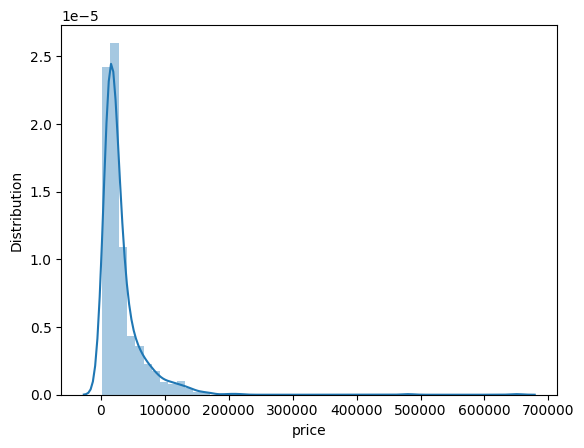

In [ ]:
sns.distplot(data['price'])
plt.xlabel('price')
plt.ylabel('Distribution')
plt.show()

<Axes: ylabel='price'>

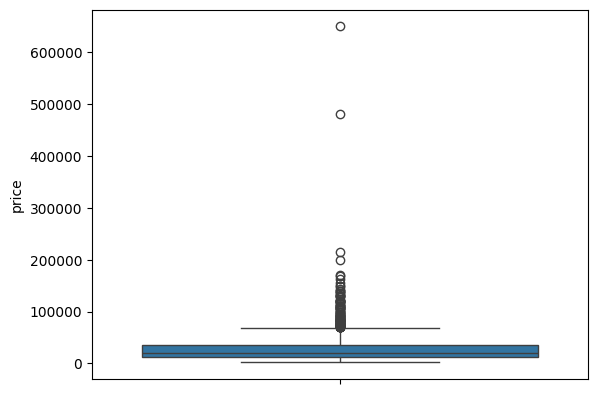

In [ ]:
sns.boxplot(data['price'])

In [ ]:
data=data[data['price']<150000]

<ipython-input-99-1b0db05ddc3b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(data['price']))


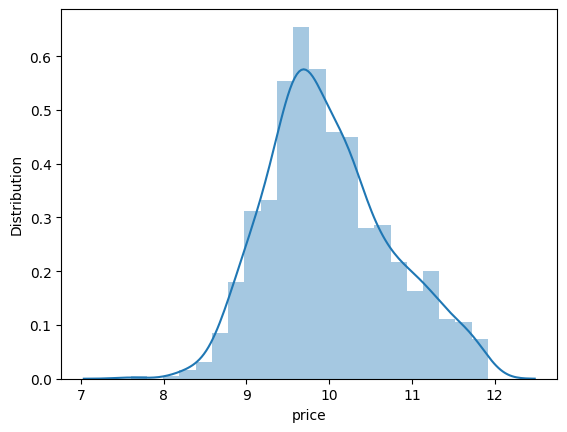

In [ ]:
sns.distplot(np.log(data['price']))
plt.xlabel('price')
plt.ylabel('Distribution')
plt.show()

<Axes: ylabel='rating'>

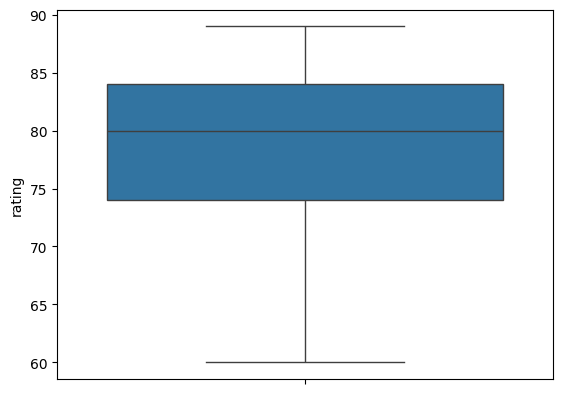

In [ ]:
sns.boxplot(data['rating'])

<Axes: xlabel='rating', ylabel='price'>

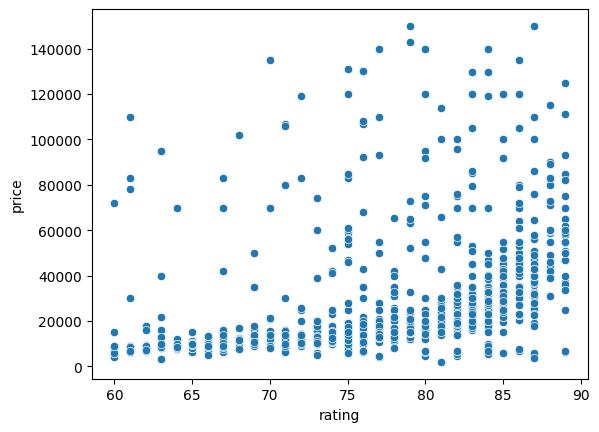

In [ ]:
sns.scatterplot(x=data['rating'],y=data['price']) # not a good co-realtion

In [ ]:
data.describe()

,price,rating,battery,has_5G,has_NFC,has_IR_BLASTER,RAM,inbuit_memory,inches,memoryCard,total_rear_mp,front_camera_mp
count,965.000000,965.00000,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000
mean,29521.821762,78.20829,4781.068394,0.556477,0.391710,0.160622,6.534715,134.018653,6.629420,0.892228,68.812788,16.124352
std,26395.547729,7.40592,1109.641262,0.497058,0.488386,0.367372,2.735597,81.727330,1.518426,0.310253,40.972282,10.607241
min,1999.000000,60.00000,5.000000,0.000000,0.000000,0.000000,1.000000,8.000000,3.540000,0.000000,6.000000,1.000000
25%,12999.000000,74.00000,4500.000000,0.000000,0.000000,0.000000,4.000000,64.000000,6.500000,1.000000,52.000000,8.000000
50%,19990.000000,80.00000,5000.000000,1.000000,0.000000,0.000000,6.000000,128.000000,6.580000,1.000000,63.000000,16.000000
75%,34990.000000,84.00000,5000.000000,1.000000,1.000000,0.000000,8.000000,128.000000,6.670000,1.000000,77.000000,16.000000
max,149999.000000,89.00000,22000.000000,1.000000,1.000000,1.000000,18.000000,512.000000,50.000000,1.000000,262.000000,60.000000


<Axes: ylabel='battery'>

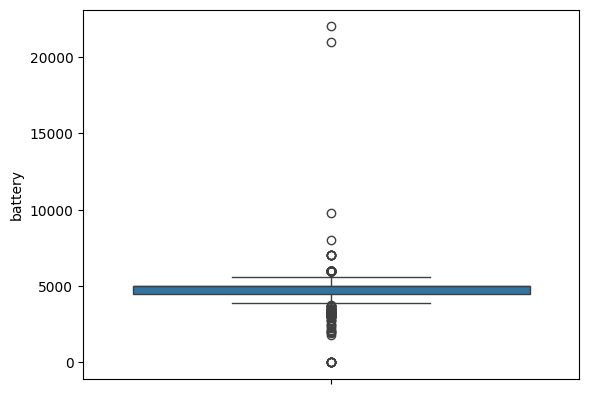

In [ ]:
sns.boxplot(data['battery']) # the best tactics to remove outlier is to use interquantile range here

In [ ]:
data=data[data['battery']>2800]

In [ ]:
data=data[data['battery']<=7000]

<Axes: ylabel='battery'>

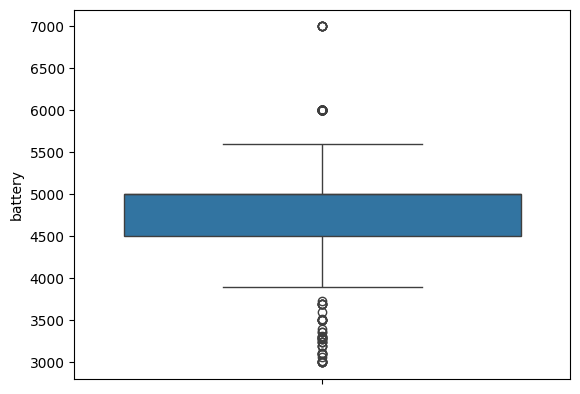

In [ ]:
sns.boxplot(data['battery'])

In [ ]:
data[data['battery']>6000]

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
217,9999,74.0,7000,tecno,0,0,0,helio,octa,4,64,6.95,1,Android,54.0,triple,8
278,13799,77.0,7000,tecno,0,0,0,helio,octa,6,128,6.90,1,Android,54.0,triple,8
484,21999,84.0,7000,samsung,1,1,0,dimensity,octa,6,128,6.70,1,Android,108.0,quad,32
850,23999,83.0,7000,samsung,0,1,0,exynos,octa,6,128,6.71,1,Android,104.0,quad,32
880,13990,67.0,7000,tecno,0,0,0,helio,octa,6,128,6.82,1,Android,20.0,dual,8
901,10999,74.0,7000,tecno,0,0,0,helio,octa,4,64,6.95,1,Android,64.0,quad,8


<Axes: ylabel='inches'>

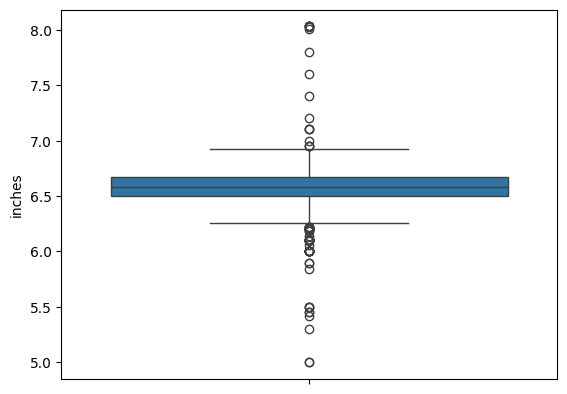

In [ ]:
sns.boxplot(data['inches'])

In [ ]:
data[data['inches']<6] # these are not outliers

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
282,69990,70.0,3500,apple,0,1,0,other,other,6,128,5.42,0,IOS,26.0,dual,12
352,4649,80.0,3500,other,0,0,0,other,quad,2,32,5.45,1,Android,17.0,Other,8
456,63990,86.0,4300,other,1,1,0,snapdragon,octa,8,128,5.90,1,other,64.0,dual,12
478,3990,60.0,3500,other,0,0,0,snapdragon,octa,3,32,5.50,1,Android,23.0,dual,5
481,5990,75.0,3020,other,0,0,0,other,quad,2,32,5.00,1,Android,6.0,Other,3
597,7499,86.0,3000,other,0,0,0,other,quad,3,32,5.50,1,Android,37.0,Other,8
738,5249,66.0,3000,nokia,0,0,0,other,octa,2,16,5.45,1,Android,15.0,Other,5
856,4999,73.0,3000,samsung,0,0,0,other,quad,1,16,5.30,1,Android,60.0,Other,5
869,17990,69.0,3100,samsung,0,0,0,exynos,octa,4,64,5.90,1,Android,53.0,dual,25
871,10949,66.0,3000,huawei,0,0,0,other,octa,4,64,5.84,1,Android,20.0,dual,16


<Axes: ylabel='total_rear_mp'>

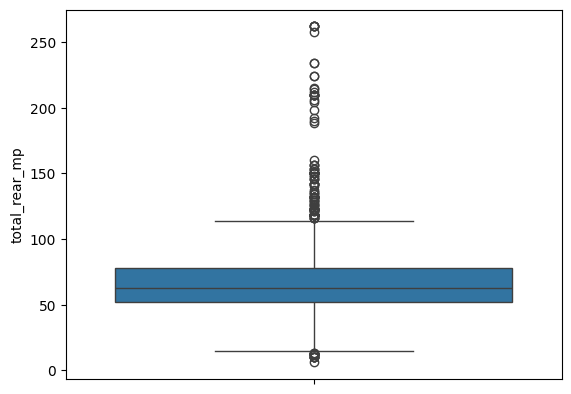

In [ ]:
sns.boxplot(data['total_rear_mp'])

In [ ]:
data['total_rear_mp']=data['total_rear_mp'].astype(int)

In [ ]:
data[data['total_rear_mp']>250] # these are not outliers

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
202,54999,82.0,4610,motorola,1,1,0,snapdragon,octa,8,128,6.67,1,other,262,triple,60
296,59999,75.0,4610,motorola,1,1,0,snapdragon,octa,12,256,6.67,1,other,262,triple,60
364,119990,85.0,5100,samsung,1,0,0,snapdragon,octa,12,256,6.83,0,Android,262,quad,60
422,41990,67.0,4450,motorola,1,1,0,snapdragon,octa,8,128,6.67,1,other,262,triple,60
761,54990,80.0,4500,other,1,1,0,snapdragon,octa,12,256,6.78,1,other,258,triple,50
945,59990,73.0,4450,motorola,1,1,0,snapdragon,octa,8,128,6.67,1,other,262,triple,60


In [ ]:
data[data['total_rear_mp']<15]

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
170,5499,82.0,4000,other,0,0,0,other,quad,4,32,6.54,1,other,12,dual,5
294,7749,61.0,5000,realme,0,0,0,other,octa,4,64,6.52,1,Android,12,Other,5
302,6299,60.0,5000,realme,0,0,0,other,octa,3,32,6.50,1,Android,12,Other,5
315,6990,82.0,4000,other,0,0,0,other,quad,2,32,6.60,1,Android,10,triple,8
337,6499,71.0,5000,samsung,0,0,0,other,quad,2,32,6.50,1,Android,12,Other,5
355,7145,86.0,5000,realme,0,0,0,other,octa,2,32,6.50,1,Android,12,Other,5
399,6490,80.0,5000,other,0,0,0,other,quad,1,16,6.50,1,other,13,dual,8
481,5990,75.0,3020,other,0,0,0,other,quad,2,32,5.00,1,Android,6,Other,3
507,7289,60.0,5000,xiaomi,0,0,0,helio,quad,2,32,6.52,1,Android,10,dual,5
595,8999,62.0,5000,realme,0,0,0,other,octa,4,64,6.50,1,Android,11,Other,5


In [ ]:
data.describe()

,price,rating,battery,has_5G,has_NFC,has_IR_BLASTER,RAM,inbuit_memory,inches,memoryCard,total_rear_mp,front_camera_mp
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,29164.676251,78.236422,4816.891374,0.560170,0.386581,0.165069,6.589989,134.253461,6.563845,0.892439,69.212993,16.286475
std,25931.104844,7.427655,568.913758,0.496631,0.487226,0.371441,2.712041,80.495796,0.246740,0.309991,41.117070,10.624926
min,3499.000000,60.000000,3000.000000,0.000000,0.000000,0.000000,1.000000,16.000000,5.000000,0.000000,6.000000,1.000000
25%,12999.000000,74.000000,4500.000000,0.000000,0.000000,0.000000,4.000000,64.000000,6.500000,1.000000,52.000000,8.000000
50%,19990.000000,80.000000,5000.000000,1.000000,0.000000,0.000000,6.000000,128.000000,6.580000,1.000000,63.000000,16.000000
75%,33824.500000,84.000000,5000.000000,1.000000,1.000000,0.000000,8.000000,128.000000,6.670000,1.000000,77.500000,16.000000
max,149999.000000,89.000000,7000.000000,1.000000,1.000000,1.000000,18.000000,512.000000,8.030000,1.000000,262.000000,60.000000


<Axes: ylabel='front_camera_mp'>

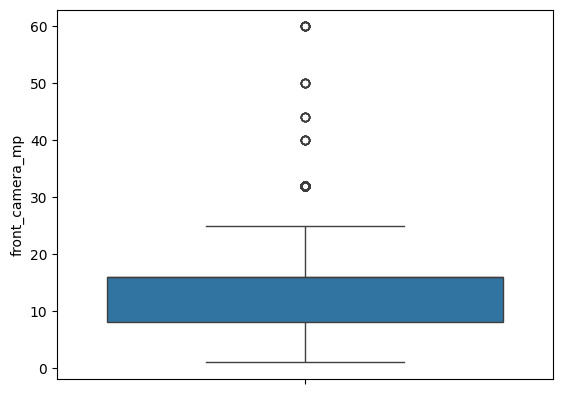

In [ ]:
sns.boxplot(data['front_camera_mp'])

In [ ]:
data[data['front_camera_mp']>=35] # these are also not outliers

,price,rating,battery,brands,has_5G,has_NFC,has_IR_BLASTER,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
28,27999,83.0,4500,vivo,1,0,0,dimensity,octa,8,128,6.44,1,Android,74,triple,50
32,27990,83.0,4700,vivo,1,0,0,dimensity,octa,8,256,6.56,1,Android,79,triple,50
37,91999,85.0,5000,samsung,1,1,0,snapdragon,octa,12,256,6.80,1,other,160,quad,40
61,29990,85.0,4600,vivo,1,1,0,snapdragon,octa,8,128,6.78,1,other,74,triple,50
65,35499,86.0,4600,vivo,1,1,0,dimensity,octa,8,256,6.78,1,other,60,triple,50
120,34999,89.0,4800,motorola,1,1,0,snapdragon,octa,8,128,6.70,1,other,102,triple,60
179,31999,85.0,4500,vivo,1,0,0,dimensity,octa,12,256,6.44,1,Android,74,triple,50
183,39999,89.0,4600,motorola,1,1,0,snapdragon,octa,8,128,6.70,1,other,112,triple,60
202,54999,82.0,4610,motorola,1,1,0,snapdragon,octa,8,128,6.67,1,other,262,triple,60
239,19990,82.0,4050,vivo,0,0,0,helio,octa,8,128,6.44,1,Android,60,triple,44


In [ ]:
data.corr(numeric_only=True)['price'] # has_iR_blaster is not very usefull so removing it.

,price
price,1.000000
rating,0.380315
battery,-0.258495
has_5G,0.472297
has_NFC,0.592959
has_IR_BLASTER,-0.040113
RAM,0.585494
inbuit_memory,0.634285
inches,0.324446
memoryCard,-0.333935


In [ ]:
data.drop(columns=['has_IR_BLASTER'],inplace=True)

In [ ]:
data.head()

,price,rating,battery,brands,has_5G,has_NFC,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
0,54999,89.0,5000,oneplus,1,1,snapdragon,octa,12,256,6.70,0,Android,130,triple,16
1,19989,81.0,5000,oneplus,1,0,snapdragon,octa,6,128,6.59,1,Android,68,triple,16
2,16499,75.0,5000,samsung,1,0,exynos,octa,4,64,6.60,1,Android,54,triple,13
3,14999,81.0,5000,motorola,1,0,snapdragon,octa,6,128,6.55,1,Android,60,triple,16
4,24999,82.0,5000,realme,1,0,dimensity,octa,6,128,6.70,0,Android,118,triple,16


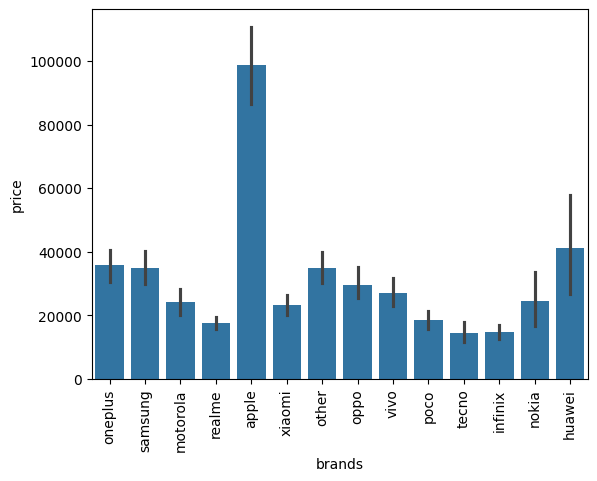

In [ ]:
sns.barplot(x=data['brands'],y=data['price'])
plt.xticks(rotation=90)
plt.show()

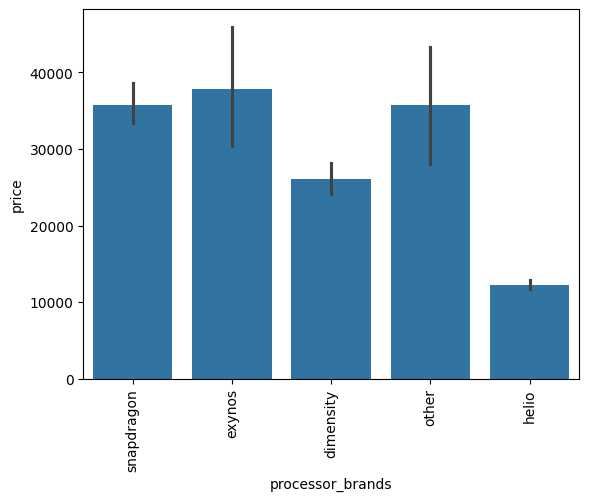

In [ ]:
sns.barplot(x=data['processor_brands'],y=data['price'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
pd.crosstab(data['brands'],data['processor_brands'])

processor_brands,dimensity,exynos,helio,other,snapdragon
brands,,,,,
apple,0,0,0,26,0
huawei,0,0,0,7,5
infinix,6,0,20,3,0
motorola,2,0,11,2,37
nokia,0,0,0,6,7
oneplus,11,0,0,0,31
oppo,23,0,23,0,42
other,8,0,11,33,83
poco,14,0,11,0,16


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 939 entries, 0 to 1019
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              939 non-null    int64  
 1   rating             939 non-null    float64
 2   battery            939 non-null    int64  
 3   brands             939 non-null    object 
 4   has_5G             939 non-null    int64  
 5   has_NFC            939 non-null    int64  
 6   processor_brands   939 non-null    object 
 7   core               939 non-null    object 
 8   RAM                939 non-null    int64  
 9   inbuit_memory      939 non-null    int64  
 10  inches             939 non-null    float64
 11  memoryCard         939 non-null    int64  
 12  opysys             939 non-null    object 
 13  total_rear_mp      939 non-null    int64  
 14  total_rear_camera  939 non-null    object 
 15  front_camera_mp    939 non-null    int64  
dtypes: float64(2), int64(9), objec

In [ ]:
data['total_rear_camera'].unique()

array(['triple', 'dual', 'quad', 'Other'], dtype=object)

In [ ]:
mapping = {
    'other': 1,
    'dual': 2,
    'triple': 3,
    'quad': 4
}

data['total_rear_camera'] = data['total_rear_camera'].map(mapping)


In [ ]:
data['total_rear_mp']=data['total_rear_mp'].astype(int)

In [ ]:
data.isnull().sum()

,0
price,0
rating,0
battery,0
brands,0
has_5G,0
has_NFC,0
processor_brands,0
core,0
RAM,0
inbuit_memory,0


In [ ]:
data['total_rear_camera'].value_counts()


,count
total_rear_camera,
3.0,521
2.0,222
4.0,141


In [ ]:
data['total_rear_camera'].fillna(data['total_rear_camera'].median(),inplace=True)

<ipython-input-129-8b78c820abc3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['total_rear_camera'].fillna(data['total_rear_camera'].median(),inplace=True)


In [ ]:
data.isnull().sum()

,0
price,0
rating,0
battery,0
brands,0
has_5G,0
has_NFC,0
processor_brands,0
core,0
RAM,0
inbuit_memory,0


In [ ]:
x=data.drop(columns=['price'])
y=np.log(data['price'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.preprocessing import PolynomialFeatures # Changed this line
from sklearn.metrics import r2_score , mean_absolute_error
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso

In [ ]:
X_train

,rating,battery,brands,has_5G,has_NFC,processor_brands,core,RAM,inbuit_memory,inches,memoryCard,opysys,total_rear_mp,total_rear_camera,front_camera_mp
312,89.0,5000,samsung,1,1,exynos,octa,8,128,6.50,1,Android,98,4.0,32
544,87.0,3700,samsung,1,1,snapdragon,octa,8,256,6.10,1,other,72,3.0,10
204,79.0,5000,motorola,0,1,snapdragon,octa,6,128,6.60,1,Android,60,3.0,16
471,66.0,5000,realme,0,0,other,octa,2,32,6.50,1,Android,18,3.0,5
364,85.0,5100,samsung,1,0,snapdragon,octa,12,256,6.83,0,Android,262,4.0,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,87.0,5000,vivo,1,0,dimensity,octa,12,256,6.73,1,other,118,3.0,32
278,77.0,7000,tecno,0,0,helio,octa,6,128,6.90,1,Android,54,3.0,8
933,79.0,5000,tecno,1,1,dimensity,octa,6,128,6.83,1,other,54,3.0,16
454,68.0,5000,samsung,0,0,helio,octa,4,128,6.50,1,Android,47,2.0,5


# Linear regression

In [ ]:
step1=ColumnTransformer(transformers=[
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
    ('col_tnf2',StandardScaler(),[0,1,7,8,9,12,13,14])

],remainder='passthrough')

step2=LinearRegression()

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)

])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)
scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
print("R2 scores from CV:", scores)
print("Average R2 score:", scores.mean())


test_score = r2_score(y_test, y_pred)
print("R2 score on test data:", test_score)

R2 scores from CV: [0.83552181 0.87523799 0.82702297 0.83849216 0.8467611 ]
Average R2 score: 0.8446072052423581
R2 score on test data: 0.85279666135245


# Ridge regression

In [ ]:
step1=ColumnTransformer(transformers=[
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
     ('col_tnf',StandardScaler(),[0,1,7,8,9,12,13,14])
],remainder='passthrough')

step2=Ridge(alpha=10)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])



param_grid={
    'step2__alpha':[0.01,0.1,0.5,1,2,3,4,5,6,7,8,9,10,11,12]

}

grid_search=GridSearchCV(pipe,param_grid,cv=5,scoring='r2')
grid_search.fit(X_train,y_train)

best_model=grid_search.best_estimator_

y_pred=best_model.predict(X_test)




print("R2 scores ", r2_score(y_test,y_pred))
print('best parameters',grid_search.best_params_)





R2 scores  0.8522360118939507
best parameters {'step2__alpha': 2}


# Lasso regression

In [ ]:
step1=ColumnTransformer([
  ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
  ('col_tnf2',StandardScaler(),[0,1,7,8,9,12,13,14])
],remainder='passthrough')


step2=Lasso()

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])

param_grid={
    'step2__alpha':[0.1,0.01,0.10,0.15,0.20,0,5,1,2,3,4,5,6,7]


}



grid_search=GridSearchCV(pipe,param_grid,cv=5,scoring='r2')
grid_search.fit(X_train,y_train)

best_paramter=grid_search.best_params_

y_pred=grid_search.predict(X_test)




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.377e+01, tolerance: 3.593e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

In [ ]:

print('R2 score',r2_score(y_test,y_pred))
print('best parameters',best_paramter)



R2 score 0.8527966613524498
best parameters {'step2__alpha': 0}


# polynomial regression

In [ ]:
pipeline_for_polynomial_regression=Pipeline([
    ('poly',PolynomialFeatures(degree=2)),
    ('scaling',StandardScaler())
])

preprocessing = ColumnTransformer(transformers=[
    ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
    ('col_tnf2',pipeline_for_polynomial_regression,[0,1,7,8,9,12,13,14])
],remainder='passthrough')


 # giving best result only on degree 1 :)

step2=LinearRegression()


pipe=Pipeline([
    ('preprocessing',preprocessing),
    ('model',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')
print("R2 scores from CV:", scores)
print("Average R2 score:", scores.mean())

print("r2 score :",r2_score(y_test,y_pred))


R2 scores from CV: [0.84620074 0.87659545 0.82119032 0.83879723 0.75762187]
Average R2 score: 0.8280811203987802
r2 score : 0.8931326945444535


# Decision tree
will see this later




In [ ]:
from sklearn.tree import DecisionTreeRegressor

step1=ColumnTransformer([
  ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
  ('col_tnf2',StandardScaler(),[0,1,7,8,9,12,13,14])
],remainder='passthrough')

step2=DecisionTreeRegressor( # this is best parametrs , cheked by hyperparameter tuning
    max_depth=7,
    min_samples_split=4,
    min_samples_leaf=4,

)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

scores=cross_val_score(pipe,X_train,y_train,cv=6,scoring='r2')
print("R2 scores from CV:", scores)
print("Average R2 score:", scores.mean())
print("test score :",r2_score(y_test,y_pred))



R2 scores from CV: [0.76803341 0.85686767 0.83579313 0.79395671 0.84179877 0.84520548]
Average R2 score: 0.8236091942568996
test score : 0.8313291953516364


#Random forest regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor


step1=ColumnTransformer([
  ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
  ('col_tnf2',StandardScaler(),[0,1,7,8,9,12,13,14])
],remainder='passthrough')

step2=RandomForestRegressor(n_estimators=100,
                           min_samples_split=4,
                           min_samples_leaf=2,
                            max_depth=8)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)

scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')
print("R2 scores from CV:", scores)
print("Average R2 score:", scores.mean())
print("test score :",r2_score(y_test,y_pred))

R2 scores from CV: [0.84022515 0.87112412 0.90117125 0.86063717 0.88780811]
Average R2 score: 0.872193161056724
test score : 0.9101975971761884


# Gradient boosting regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

step1=ColumnTransformer([
  ('col_tnf1',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
  ('col_tnf2',StandardScaler(),[0,1,7,8,9,12,13,14])
],remainder='passthrough')

step2=GradientBoostingRegressor(n_estimators=100,
                                learning_rate=0.1,
                                max_depth=8,
                                min_samples_split=4,
                                min_samples_leaf=2,
                                subsample=0.95


)


pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred=pipe.predict(X_test)


scores=cross_val_score(pipe,X_train,y_train,cv=5,scoring='r2')
print("R2 scores from CV:", scores)
print("Average R2 score:", scores.mean())
print("test score :",r2_score(y_test,y_pred))

R2 scores from CV: [0.83726643 0.87989988 0.89388877 0.8569643  0.88920334]
Average R2 score: 0.8714445438949887
test score : 0.9151760517625244


#XGBOOST REGRESSOR

In [ ]:
from xgboost import XGBRegressor

step1=ColumnTransformer([
         ('encoding',OneHotEncoder(sparse_output=False,drop='first'),[2,5,6,11]),
         ('scaling',StandardScaler(),[0,1,7,8,9,12,13,14])
],remainder='passthrough')

step2=XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,

    subsample=0.80,

)

pipe=Pipeline([
    ('step1',step1),
    ('step2',step2)
])


param_grid={
    'step2__n_estimators':[50,100,150,200],
    'step2__learning_rate':[0.01,0.05,0.1,0.2],
    'step2__max_depth':[3,5,7,9]

}
grid_search=GridSearchCV(pipe,param_grid=param_grid,cv=5,scoring='r2')

grid_search.fit(X_train,y_train)

best_parameter=grid_search.best_params_

print("best parametere :",best_parameter)

print("best scorre",grid_search.best_score_)

y_pred=grid_search.predict(X_test)

print("test score :",r2_score(y_test,y_pred))



best parametere : {'step2__learning_rate': 0.1, 'step2__max_depth': 3, 'step2__n_estimators': 200}
best scorre 0.896328647967622
test score : 0.8962147785866206
